# Artists

In Matplotlib, an *Artist* is any object that knows how to draw itself onto a canvas. Everything you see in a Matplotlib figure is actually an *artist*:

- The figure itself
- The axes (plotting area)
- Lines, shapes, text
- Axis labels, tick marks, legends

Most of the plot functions that you have used thus far call the *artists* you will explore next. You can think of *artists* as the building blocks of Matplotlib. Sometimes we want to access them directly.

## The Artist Hierarchy

Artists are organized in a hierarchical structure:

```
Artist (base class)
├── Container Artists
│   ├── Figure
│   ├── Axes
│   └── Axis
└── Primitive Artists
    ├── Line2D
    ├── Patch (Rectangle, Circle, Polygon, Wedge, PathPatch, etc.)
    ├── Text
    ├── Image
    └── Collection
```

## Two Main Categories

1. **Container Artists**: Hold and organize other artists (Figure, Axes, Axis). You have already encountered all *container artists*, i.e. there are artists that organize and hold other artists. They don't draw visual elements themselves but manage the layout and positioning of primitive artists:
- Figure
- Axes
- Axis
2. **Primitive Artists**: Actual visual elements that render on screen (lines, shapes, text, etc.). This are the ones we are going concentrate on.

Understanding artists gives you fine-grained control over every aspect of your plots, beyond what high-level functions like `ax.plot()` provide.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

### Primitive Artists

Primitive artists are the visual elements that actually render on the plot. Let's explore each type in detail.


#### Line2D

`Line2D()` creates lines. `.plot()` calls `Line2D()`. 

**Main Line Parameters:**

We have seen these when drawin lines with `ax.plot()`.

- `xdata`: array-like. Default: `[]`. Range: Any numeric values. E.g. `[0, 1, 2, 3, 4]`
- `ydata`: array-like. Default: `[]`. Range: Any numeric values. E.g. `[0, 1, 4, 9, 16]`
- `linewidth` or `lw`: float. Default: `1.5`. Range: any positive value (typically 0-10). E.g. `2.5`
- `linestyle` or `ls`: str. Default: `'-'` (solid). Range: `'-'`, `'--'`, `'-.'`, `':'`, or `''` (no line). E.g. `'--'`
- `color` or `c`: color specification. Default: Next color in cycle (usually `'C0'`). Range: Named colors, hex codes, RGB tuples. E.g. `'red'`, `'#FF5733'`, `(0.1, 0.2, 0.5)`
- `marker`: str. Default: `None`. Range: `'o'`, `'s'`, `'^'`, `'*'`, `'+'`, `'x'`, etc. E.g. `'o'`
- `markersize` or `ms`: float. Default: `6.0`. Range: `0` to any positive value. E.g. `10`
- `alpha`: float. Default: `1.0`. Range: `0.0` (transparent) to `1.0` (opaque). E.g. `0.7`
- `label`: str. Default: `''`. Range: Any string. E.g. `'My Data'`


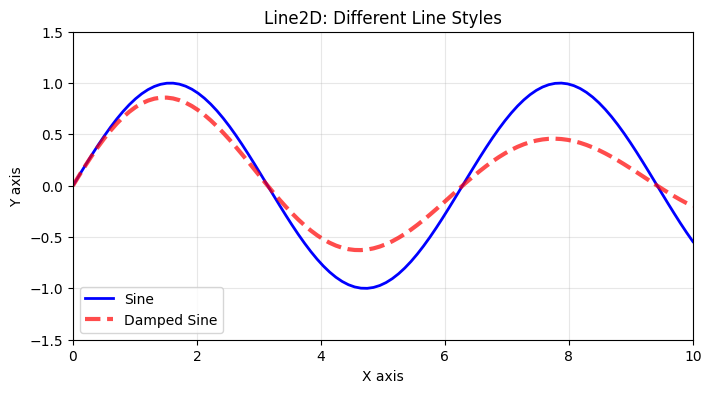

In [2]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(8, 4))

# Create data
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.sin(x) * np.exp(-x/10)

# Create Line2D objects manually
line1 = Line2D(x, y1, lw=2, ls='-', color='blue', label='Sine')
line2 = Line2D(x, y2, lw=3, ls='--', color='red', alpha=0.7, label='Damped Sine')

# Add lines to axes
ax.add_line(line1)
ax.add_line(line2)

# Set axis limits (required when adding artists manually)
ax.set_xlim(0, 10)
ax.set_ylim(-1.5,1.5)
#

ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_title('Line2D: Different Line Styles')
ax.legend()
ax.grid(True, alpha=0.3)


plt.show()


#### Patch Artists

Patches are 2D artists that represent **filled shapes**. The `Patch` class is the base class for all patch types.

Common patch types:
- `Rectangle`
- `Circle`
- `Polygon`
- `Wedge`
- `Ellipse`
- `FancyBboxPatch`
- `PathPatch` (most flexible)

You use

In [3]:
# import matplotlib patches
import matplotlib.patches as mpatches

to access the different patch types.

####  Rectangle

`Rectangle` is used for:
- Creating bar charts manually
- Highlighting regions of a plot
- Creating heatmap cells
- Drawing boxes, frames, or borders
- Building custom shapes from rectangles

**Main rectangle parameter:**

- `height`: float. **Required**.  
- `angle`: float. Default: `0.0`. Range: `0`–`360` degrees.  
- `facecolor` or `fc`: color specification. Default: `'C0'`.  
- `edgecolor` or `ec`: color specification. Default: `'black'`.  
- `linewidth` or `lw`: float. Default: `1.0`.  
- `linestyle` or `ls`: str. Default: `'-'`.  
- `alpha`: float. Default: `1.0` (0.0 transparent to 1.0 opaque)

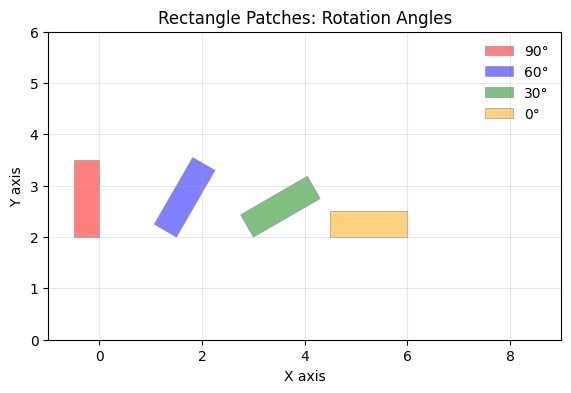

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))

# Create rotated rectangles
angles = [90, 60, 30, 0]
colors = ['red', 'blue', 'green', 'orange']

for i, (angle, color) in enumerate(zip(angles, colors)):
    rect = mpatches.Rectangle((1.5*i, 2),
                              width=1.5, height=0.5, 
                              angle=angle,
                              fc=color,ec='grey',
                              lw=.75, alpha=0.5,
                              label= f'{angle}°')
    ax.add_patch(rect)

#set limits
ax.set_xlim(-1, 9)
ax.set_ylim(0, 6)

ax.set_aspect('equal')
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_title('Rectangle Patches: Rotation Angles')
ax.legend(loc='upper right', frameon= False)
ax.grid(True, alpha=0.3)

plt.show()

#### Circle

`Circle` is used for:
- Creating bubble charts
- Highlighting specific points
- Drawing circular annotations
- Visualizing spatial data or regions
- Creating pie chart-like visualizations

**Main Circle Parameters:**

- `xy`: tuple (x, y). *Required*
- `radius`: float. *Required*. Range: Any positive value
- `facecolor` or `fc`: color specification. Default: `'C0'`. Example: `'skyblue'`
- `edgecolor` or `ec`: color specification or `None`. Default: `'black'`. Example: `'navy'`
- `linewidth` or `lw`: float. Default: `1.0`. Example: `2.0`
- `alpha`: float. Default: `1.0`. Range: `0.0` to `1.0`. Example: `0.6`
- `fill`: bool. Default: `True`. Example: `False` (draws only the outline)


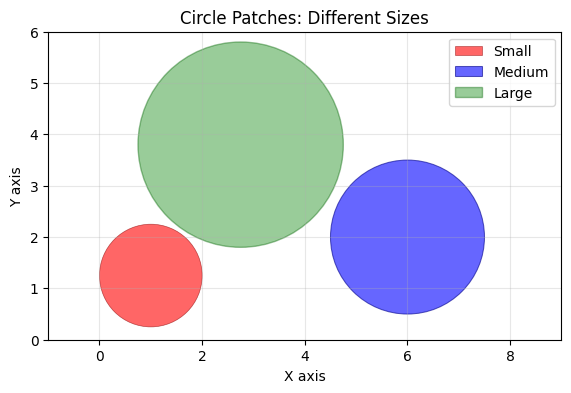

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))

# Create circles with different radii
circle1 = mpatches.Circle((1, 1.25), radius=1,
                          fc='red', ec='darkred',
                          lw=0.5, alpha=0.6,
                          label='Small')

circle2 = mpatches.Circle((6, 2), radius=1.5,
                          fc='blue', ec='darkblue',
                          lw=0.75, alpha=0.6,
                          label='Medium')

circle3 = mpatches.Circle((2.75, 3.8), radius=2,
                            fc='green', ec='darkgreen',
                            lw=1, alpha=0.4,
                            label='Large')

ax.add_patch(circle1)
ax.add_patch(circle2)
ax.add_patch(circle3)

# set plot limits
ax.set_xlim(-1, 9)
ax.set_ylim(0, 6)

ax.set_aspect('equal')
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_title('Circle Patches: Different Sizes')
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

#### Polygon

`Polygon` is used for:
- Creating custom multi-sided shapes (triangles, pentagons, hexagons, etc.)
- Visualizing geographic boundaries
- Drawing irregular shapes
- Creating mosaic or tessellation patterns
- Building complex custom visualizations

**Main Polygon Parameters:**

- `xy`: array-like of shape (N, 2). **Required**. E.g. `[[0, 0], [1, 0], [0.5, 1]]` (triangle)
- `closed`: bool. Default: `True`. Range: `True` (closes polygon) or `False` (open path)
- `facecolor` or `fc`: color specification. Default: `'C0'`. Range: Named colors, hex codes, RGB tuples. Example: `'yellow'`
- `edgecolor` or `ec`: color specification. Default: `'black'`. Range: Named colors, hex codes, RGB tuples, or `None`. Example: `'black'`
- `linewidth` or `lw`: float. Default: `1.0`. Range: `0` to any positive value. Example: `2.0`
- `alpha`: float. Default: `1.0`. Range: `0.0` to `1.0`. Example: `0.7`


#### Create a polygon

In [6]:
x, y = 1, 2
angles = np.linspace(0, 2*np.pi, 3+1)#triangle needs one more
np.column_stack([x + np.cos(angles), y + np.sin(angles)])

array([[2.       , 2.       ],
       [0.5      , 2.8660254],
       [0.5      , 1.1339746],
       [2.       , 2.       ]])

We are creating our own function to generate any regular polygon

In [7]:
def polygonN(cx, cy, n):
    ''' creates a polygon of any side 
    x, y: float - position of the polygon center
    n: integer - number of sides
    '''
    import numpy as np
    
    if n<3: return
    angles = np.linspace(0,2*np.pi, n+1)
    return np.column_stack([cx + np.cos(angles), cy + np.sin(angles)])

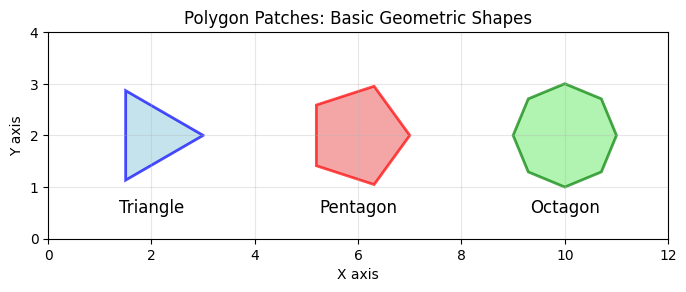

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

# Triangle
n= 3
x, y = 2,2
triangle= polygonN(x,y,n)
poly1 = mpatches.Polygon(triangle,
                         fc='lightblue', ec='blue',
                         lw=2, alpha=0.7)
# Pentagon
n = 5
x, y = 6, 2
pentagon =  polygonN(x,y,n)
poly2 = mpatches.Polygon(pentagon,
                         fc='lightcoral', ec='red',
                         lw=2, alpha=0.7)
# Octagon
n= 8
x, y = 10, 2
octagon =  polygonN(x,y,n)
poly3 = mpatches.Polygon(octagon,
                         fc='lightgreen', ec='green',
                         lw= 2, alpha=0.7)
# Add patches
ax.add_patch(poly1)
ax.add_patch(poly2)
ax.add_patch(poly3)

# Add labels
ax.text(2, 0.5, 'Triangle', ha='center', size=12)
ax.text(6, 0.5, 'Pentagon', ha='center', size=12)
ax.text(10, 0.5, 'Octagon', ha='center', size=12)

ax.set_xlim(0, 12)
ax.set_ylim(0, 4)
ax.set_aspect('equal')
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_title('Polygon Patches: Basic Geometric Shapes')
ax.grid(True, alpha=0.3)
plt.show()

Let's try some other forms. Here is a function that will create Stars....

In [9]:
# Star shape (5-pointed star)
def create_star(cx, cy, r_outer, r_inner, n=5):
    '''cx, cy : floats - star center position
       r_outer: float - outer radius
       r_inner: float - inner radius
       n: integer - number of points '''
     
    angles = np.linspace(0, 2*np.pi, 2*n + 1)
    radii = np.tile([r_outer, r_inner], n)
    radii = np.append(radii, r_outer)
    x = cx + radii * np.cos(angles - np.pi/2)
    y = cy + radii * np.sin(angles - np.pi/2)
    return np.column_stack([x, y])

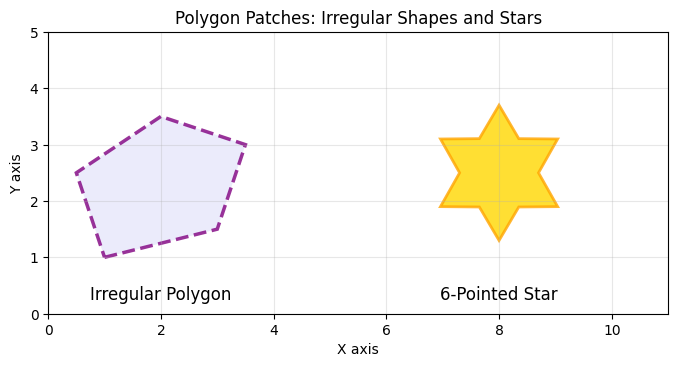

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))

# Irregular polygon
irregular = np.array([[1, 1], [3, 1.5], [3.5, 3], [2, 3.5], [0.5, 2.5]])
poly1 = mpatches.Polygon(irregular,
                         fc='lavender', ec='purple',
                         lw=2.5, ls='--', alpha=0.8)

# Star shape polygon
n = 6
r_outer= 1.2
r_inner =0.7

star = create_star(8, 2.5, r_outer, r_inner, n)
poly2 = mpatches.Polygon(star,
                         fc='gold', ec='orange',
                         lw=2, alpha=0.8)

# Add patches
ax.add_patch(poly1)
ax.add_patch(poly2)

# Ancillary
ax.text(2, 0.25, 'Irregular Polygon', ha='center', fontsize=12)
ax.text(8, 0.25, f'{n}-Pointed Star', ha='center', fontsize=12)

# Set plot limits
ax.set_xlim(0, 11)
ax.set_ylim(0, 5)

ax.set_aspect('equal')
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_title('Polygon Patches: Irregular Shapes and Stars')
ax.grid(True, alpha=0.3)

plt.show()

#### Wedge

`Wedge` is used for:
- Creating custom pie charts
- Drawing circular sectors
- Visualizing angular data
- Creating donut charts
- Highlighting angular ranges

**Main Wedge Parameters:**

- `center`: tuple (x, y). **Required**. Example: `(0, 0)`
- `r`: float. **Required**. Range: Any positive value (outer radius). Example: `1.0`
- `theta1`: float. **Required**. Range: `0` to `360` degrees (starting angle). Example: `0`
- `theta2`: float. **Required**. Range: `0` to `360` degrees (ending angle). Example: `90`
- `width`: float or `None`. Default: `None` (filled wedge). Range: `0` to `r` (creates a ring/donut if set). Example: `0.3` (for donut chart)
- `facecolor` or `fc`: color specification. Default: `'C0'`. Range: Named colors, hex codes, RGB tuples. Example: `'tomato'`
- `edgecolor` or `ec`: color specification or `None`. Default: `'black'`. Range: Named colors, hex codes, RGB tuples. Example: `'white'`
- `alpha`: float. Default: `1.0`. Range: `0.0` to `1.0`. Example: `0.8`

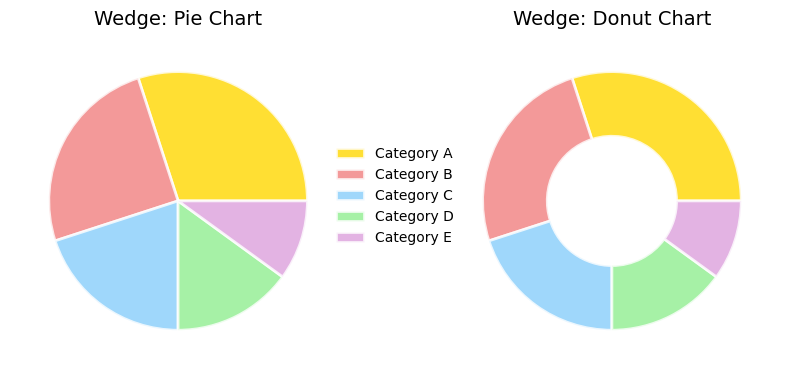

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

# Pie chart data
sizes = [30, 25, 20, 15, 10]
colors = ['gold', 'lightcoral', 'lightskyblue', 'lightgreen', 'plum']
labels = ['Category A', 'Category B', 'Category C', 'Category D', 'Category E']

# Create pie chart using Wedges
start_angle = 0
for size, color, label in zip(sizes, colors, labels):
    angle = (size/100)*360#  # Convert percentage to degrees
    wedge = mpatches.Wedge(center=(0, 0), r=1,
                           theta1=start_angle, theta2=start_angle + angle, 
                           fc=color, ec='white', 
                           lw=2, alpha=0.8, label=label)
    
    # adding one wedge at a time
    ax1.add_patch(wedge)
    start_angle += angle

# set plot limits and aspect
ax1.set(xlim= (-1.3, 1.3), ylim= (-1.3, 1.3), aspect= 'equal')#reset limits
ax1.axis('off')
ax1.set_title('Wedge: Pie Chart', size=14)

ax1.legend(loc='center', bbox_to_anchor=(0.5, 0.5), frameon = False, bbox_transform= fig.transFigure)

# Create donut chart using Wedges with width parameter
start_angle = 0
for size, color, labe in zip(sizes, colors, labels):
    angle = size * (360/100)
    wedge = mpatches.Wedge(center=(0, 0), r=1,
                           theta1=start_angle, theta2=start_angle + angle,
                           width= 0.5,#, # this is what makes it Top Pot!
                           fc=color, ec='white', 
                           lw=2, alpha=0.8)
    ax2.add_patch(wedge)
    start_angle += angle

ax2.set(xlim= (-1.3, 1.3), ylim= (-1.3, 1.3), aspect= 'equal')
ax2.axis('off')
ax2.set_title('Wedge: Donut Chart', size=14)

fig.tight_layout()
plt.show()

### Path and PathPatch

`Path` and `PathPatch` are used for:
- Creating completely custom shapes
- Drawing bezier curves
- Building complex vector graphics
- Creating smooth, curved shapes
- Maximum flexibility when other patches don't suffice

`Path` defines the geometry, `PathPatch` makes it drawable.

To access these use the following imports:

In [12]:
from matplotlib.path import Path
from matplotlib.patches import PathPatch

A `Path` is a collection of `vertices` connected by different types of path `codes` that define how to connect them:
  1. `Vertices`: Array of  N (x, y) coordinates.E.g. `[[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]]`
  2. `Codes`: Array of N instructions on how to connect vertices. E.g. `[Path.MOVETO, Path.LINETO, Path.LINETO, Path.CLOSEPOLY]`.    
     Codes can be:    
    - `Path.MOVETO` (1): Move to a point without drawing  
    - `Path.LINETO` (2): Draw a straight line to the point    
    - `Path.CURVE3` (3): Quadratic Bezier curve (2 control points)    
    - `Path.CURVE4` (4): Cubic Bezier curve (3 control points)    
    - `Path.CLOSEPOLY`(79): Close the path by drawing a line to the start    

A `PathPatch` contains a `path' as defined above plus any of the following parameters:
- `facecolor` or `fc`. : Named colors, hex codes, RGB tuples. Default: `'C0'`
- `edgecolor` or `ec`: Named colors, hex codes, RGB tuples. Default: `'black'`
- `linewidth` or `lw`: float. Default: `1.0`. Range: `0` to any positive value
- `alpha`: float. Default: `1.0`. Range: `0.0` to `1.0`

Let's create two disconnected rectangles using a path.
#### Disconnected squares

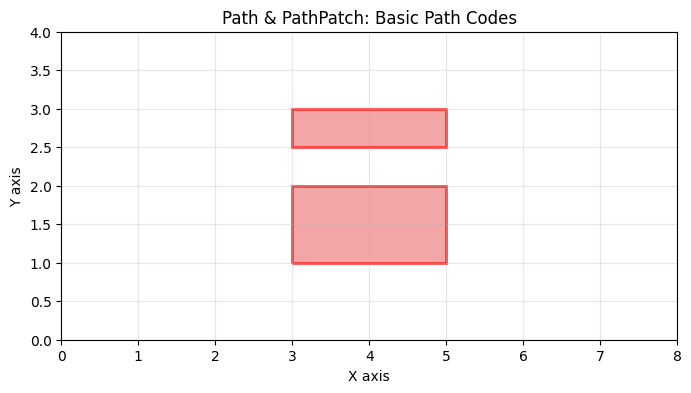

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))

# Create a path with a gap (using MOVETO)
vertices = [
    (3, 1),    # Start
    (5, 1),    # Line
    (5, 2),    # Line
    (3, 2),    # Move without drawing (creates gap)
    (3, 1),    # line
    (3, 2.5),  # Start new segment
    (5, 2.5),  # Line
    (5, 3),    # Line
    (3, 3),    # Line
    (3, 2.5),  # Close
]

codes = [
    Path.MOVETO,
    Path.LINETO,
    Path.LINETO,
    Path.LINETO,
    Path.LINETO,
    Path.MOVETO,    # Creates a gap
    Path.LINETO,
    Path.LINETO,
    Path.LINETO,
    Path.CLOSEPOLY,
]
# Create the patch
path = Path(vertices, codes)
patch = PathPatch(path,
                  fc='lightcoral', ec='red', 
                  lw=2, alpha=0.7)
ax.add_patch(patch)

ax.set(xlim= (0, 8),
       ylim= (0, 4),
       aspect = 'equal',
       xlabel='X axis',
       ylabel='Y axis')
ax.set_title('Path & PathPatch: Basic Path Codes')
ax.grid(True, alpha=0.3)

plt.show()

#### Bezier Curves with Path

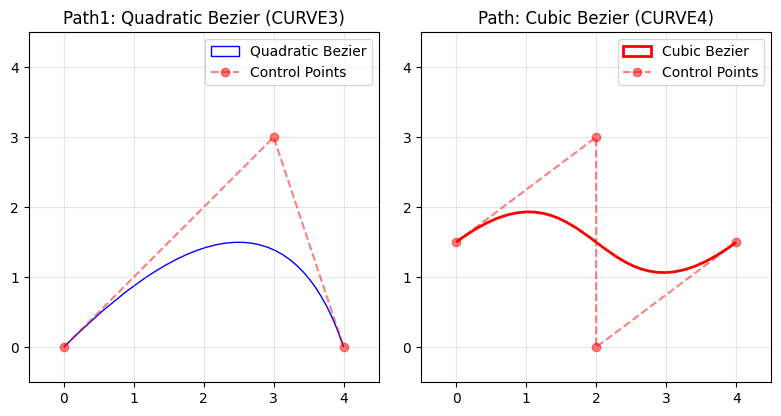

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))


# Path 1: a quadratic Bezier curve (CURVE3)
# CURVE3 uses 3 points: start, control, end
vertices1 = [(0, 0),      # Start (MOVETO)
             (3, 3),      # Control point (CURVE3)
             (4, 0),]     # End point (CURVE3)
codes1 = [
    Path.MOVETO,
    Path.CURVE3,
    Path.CURVE3,
]

path1 = Path(vertices1, codes1)
patch1 = PathPatch(path1, fc='none', ec='blue', 
                       lw=1, label='Quadratic Bezier')#uses codes
ax1.add_patch(patch1)#add path to patch

# Plot control points
verts = np.array(vertices1)
ax1.plot(verts[:, 0], verts[:, 1], 'ro--', alpha=0.5, label='Control Points')
ax1.set(xlim= (-0.5, 4.5), ylim= (-0.5, 4.5), aspect= 'equal')
ax1.set_title('Path1: Quadratic Bezier (CURVE3)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Path2: a cubic Bezier curve (CURVE4)
# CURVE4 uses 4 points: start, control1, control2, end
vertices2 = [(0, 1.5),      # Start (MOVETO) 0.0
             (2, 3),        # Control point 1 (CURVE4) 1,3
             (2, 0),        # Control point 2 (CURVE4) 3,3
             (4, 1.5),]     # End point (CURVE4) 4,0
codes2 = [Path.MOVETO,
          Path.CURVE4,
          Path.CURVE4,
          Path.CURVE4]

path2= Path(vertices2, codes2)
patch2 = PathPatch(path2, fc='none', ec='red', 
                   lw=2, label='Cubic Bezier')
ax2.add_patch(patch2)

# Plot control points
verts = np.array(vertices2)
ax2.plot(verts[:, 0], verts[:, 1], 'ro--', alpha=0.5, label='Control Points')

ax2.set(xlim= (-0.5, 4.5), ylim= (-0.5, 4.5), aspect= 'equal')
ax2.set_title('Path: Cubic Bezier (CURVE4)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### E. Collections

#### When to Use

Collections are optimized for drawing many similar artists efficiently:

- **`LineCollection`**
- **`PathCollection`**
- **`PolyCollection`**
- **`PatchCollection`**
- **`RegularPolyCollection`**
- **`EllipseCollection`**
- **...**

**Key Advantages**:
- Much faster than individual artists for large datasets
- Single draw call for all objects
- Efficient memory usage

**When to use Collections vs Individual Artists**:
- Use **Collections** when: Drawing 100+ similar objects, performance matters, objects share properties
- Use **Individual Artists** when: Each object is unique, fine-grained control needed, small number of objects (<50)

Collections deserve their own in-depth tutorial due to their complexity and power.

Here is a really pretty 🤗 creation


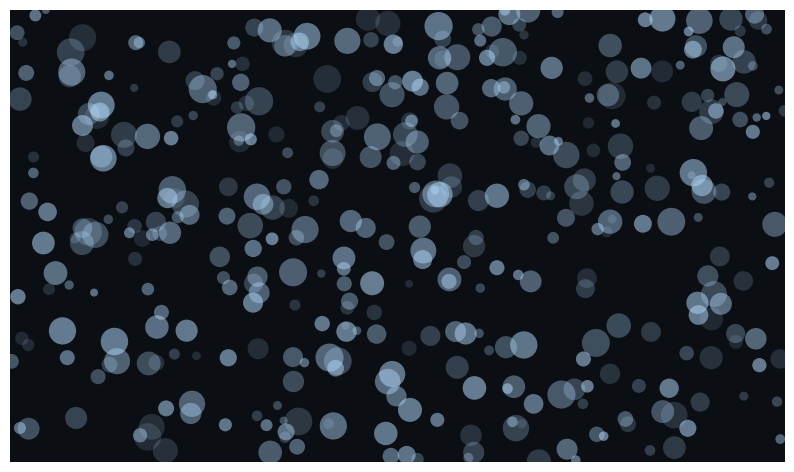

In [15]:
from matplotlib.collections import EllipseCollection

rng = np.random.default_rng(seed=2026)

# main parameters to create the collection
n = 400
xlim = (0, 12)
ylim = (0, 7)


# Create Random centers based on axes data limits for the circles
xs = rng.uniform(*xlim, n)
ys = rng.uniform(*ylim, n)
offsets = np.column_stack([xs, ys])

# Create n random radii (= widths/heights) in data units
r = rng.uniform(0.06, 0.22, n)
widths  = 2.0 * r # widths=heights for circles
heights = 2.0 * r
angles  = np.zeros(n)  # 0 circles have no orientation

# Same color, different alphas (transparencies)
color = np.array([0.70, 0.86, 1.0])        # pale blue single drop
colors = np.tile(color, (n, 1)) # n rows
alphas   = rng.uniform(0.12, 0.55, n)
facecolors = np.column_stack([colors, alphas])

# create figure and axes
fig, ax = plt.subplots(figsize=(10, 6))

# set plot limits
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

# styling the figure and axes
ax.set_aspect("equal")
ax.set_facecolor("#0b0f14") # Minimal styling to showcase alpha
ax.set_xticks([]); ax.set_yticks([]) # no ticks
for s in ax.spines.values(): # no spines
    s.set_visible(False)

coll = EllipseCollection(
    widths, heights, angles,
    units="xy",
    offsets=offsets,
    transOffset=ax.transData,   # interpret offsets in data coords
    fc=facecolors,ec="none",
    antialiased=True
)

ax.add_collection(coll)
plt.show()

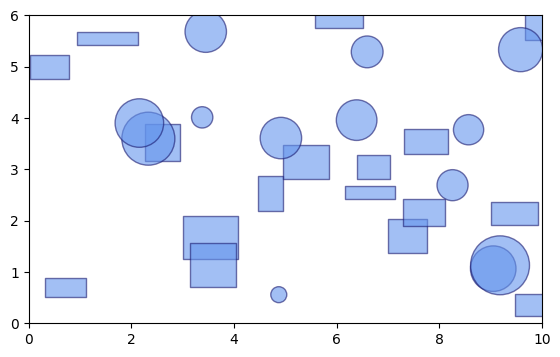

In [16]:
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle, Circle
n = 30
rng = np.random.default_rng(2026)
patches = []

# Mix of rectangles and circles (arbitrary shapes allowed)
for _ in range(n):
    # shape decider
    if rng.random() < 0.5:
        # rectangles
        x, y = rng.uniform(0, 10), rng.uniform(0, 6)
        w, h = rng.uniform(0.3, 1.2), rng.uniform(0.2, 1.0)
        patches.append(Rectangle((x, y), w, h))
    else:
        # circles
        x, y = rng.uniform(0, 10), rng.uniform(0, 6)
        r = rng.uniform(0.15, 0.6)
        patches.append(Circle((x, y), r))

fig, ax = plt.subplots(figsize=(7, 4))
pc = PatchCollection(patches, fc="cornflowerblue", ec="midnightblue", alpha=0.6)
ax.add_collection(pc)

ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.set_aspect("equal")
plt.show()